# Phase 3: Association Rule Mining

Home Credit Default Risk, KDD Phase 3.

What this notebook does:
1. Discretize the continuous features into business-friendly bins (income, age, credit, and so on).
2. Run Apriori to find frequent itemsets and association rules.
3. Cross-check with FP-Growth and ECLAT; if three different algorithms agree, the rule is real.
4. Run FP-Growth per segment to surface rules specific to each cluster.
5. Filter to non-trivial rules (lift at least 1.2, confidence at least 0.35, and a Jaccard overlap below 0.65 to drop near-duplicates).

Input: `datasets/final/features_clustering.csv` (Phase 1) and `datasets/final/cluster_labels.csv` (Phase 2).

Outputs land in `results/phase3_association/`: the encoded transactions, the rule tables per algorithm, the combined and final rule tables, and the plots. The written interpretation of each rule lives in the project-root `REPORT.md`.

## 1. Setup and load

In [1]:
import os, time, pickle, random, ast
from pathlib import Path
from collections import defaultdict
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase3_association'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None  # None = mine SEMUA aplikasi (full dataset)
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.2
JACCARD_REDUNDANCY = 0.65

print(f'Loading features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')

if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
labels = labels.drop(columns=[c for c in ['SK_ID_CURR'] if c in labels.columns and c in features.columns])
df_all = pd.merge(features, labels, on='ROW_ID', how='inner')
assert len(df_all) == len(features), (
    f'cluster_labels.csv ({len(labels):,} rows) does not align with features ({len(features):,} rows) - re-run Phase 2!')
print(f'\nMerged: {df_all.shape}')

cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print('\nCluster naming (artefak Phase 2):')
print(cluster_names_df.to_string(index=False))

Loading features ...


  features: (356255, 48)
  labels  : (356255, 6)

Merged: (356255, 53)

Cluster naming (artefak Phase 2):
 cluster_id                nama        slug profil_risiko  n_applicants
          0   Troubled Borrower  bermasalah     Very high          3582
          1  Ambitious Borrower    ambisius        Medium        125071
          2      Active Veteran     veteran   Medium-high         46905
          3 Intensive Card User cc_intensif   Medium-high         54215
          4    Minimal Borrower     minimal    Low-medium        126482


## 2. Discretization: from continuous values to categories

How we bin: we use quantile cuts (`pd.qcut`) so each bin holds a similar number of applicants and no bin comes out empty. Simple dimensions get three bins (low, medium, high); income gets four (low, medium, high, very high). Clusters are renamed to their Phase 2 business names. The point of quantile cuts is balanced support across bins, which is exactly what Apriori needs since it is sensitive to the support threshold.

In [2]:
discretized = {}

if 'AMT_INCOME_TOTAL' in df_all.columns:
    discretized['income'] = pd.qcut(df_all['AMT_INCOME_TOTAL'], q=4,
                                     labels=['income_low','income_med','income_high','income_very_high'])
if 'YEARS_BIRTH' in df_all.columns:
    discretized['age'] = pd.qcut(df_all['YEARS_BIRTH'], q=3,
                                  labels=['age_young','age_mid','age_senior'], duplicates='drop')
if 'YEARS_EMPLOYED' in df_all.columns:
    discretized['emp_tenure'] = pd.qcut(df_all['YEARS_EMPLOYED'], q=3,
                                         labels=['emp_new','emp_mid','emp_senior'], duplicates='drop')
if all(c in df_all.columns for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']):
    ext_mean = df_all[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    discretized['risk_score'] = pd.qcut(ext_mean, q=3,
                                         labels=['risk_score_low','risk_score_med','risk_score_high'])
if 'AMT_CREDIT' in df_all.columns:
    discretized['credit_size'] = pd.qcut(df_all['AMT_CREDIT'], q=3,
                                          labels=['credit_small','credit_med','credit_large'], duplicates='drop')
if 'AMT_ANNUITY' in df_all.columns and 'AMT_INCOME_TOTAL' in df_all.columns:
    burden = df_all['AMT_ANNUITY'] / (df_all['AMT_INCOME_TOTAL'] + 1)
    discretized['burden'] = pd.qcut(burden, q=3,
                                     labels=['burden_low','burden_med','burden_high'], duplicates='drop')
if 'CLUSTER_KMEANS' in df_all.columns:
    # Mapping dibaca dari artefak Phase 2 - labeling order tidak deterministik antar run
    cluster_map = {int(r.cluster_id): f'cluster_{int(r.cluster_id)}_{r.slug}'
                   for r in cluster_names_df.itertuples()}
    discretized['cluster'] = df_all['CLUSTER_KMEANS'].map(cluster_map)

trans_df = pd.DataFrame(discretized)
for c in trans_df.columns:
    trans_df[c] = trans_df[c].astype(str).replace({'nan': f'unknown_{c}', '<NA>': f'unknown_{c}'})

print(f'Transactions table: {trans_df.shape}')
print(f'Columns: {trans_df.columns.tolist()}')
print('\nPer-column distribution:')
for c in trans_df.columns:
    print(f'\n  {c}:')
    print(trans_df[c].value_counts(normalize=True).round(3).to_string())

Transactions table: (356255, 7)
Columns: ['income', 'age', 'emp_tenure', 'risk_score', 'credit_size', 'burden', 'cluster']

Per-column distribution:

  income:
income
income_low          0.320
income_high         0.262
income_very_high    0.237
income_med          0.181

  age:
age
age_young     0.333
age_senior    0.333
age_mid       0.333

  emp_tenure:
emp_tenure
emp_mid       0.333
emp_new       0.333
emp_senior    0.333

  risk_score:
risk_score
risk_score_low     0.333
risk_score_high    0.333
risk_score_med     0.333

  credit_size:


credit_size
credit_med      0.344
credit_small    0.334
credit_large    0.322

  burden:
burden
burden_low     0.333
burden_high    0.333
burden_med     0.333

  cluster:
cluster
cluster_4_minimal        0.355
cluster_1_ambisius       0.351
cluster_3_cc_intensif    0.152
cluster_2_veteran        0.132
cluster_0_bermasalah     0.010


In [3]:
rng = random.Random(RANDOM_SEED)
if SAMPLE_SIZE is None:
    trans_sample = trans_df          # full dataset - semua aplikasi ikut dimining
else:
    trans_sample = trans_df.sample(n=min(SAMPLE_SIZE, len(trans_df)), random_state=RANDOM_SEED)

transactions_list = [[str(item) for item in row] for row in trans_sample.values.tolist()]
with open(OUT_DIR / 'transactions_list.pkl', 'wb') as f:
    pickle.dump(transactions_list, f)

te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df_ohe = pd.DataFrame(te_ary, columns=te.columns_)
df_ohe.to_pickle(OUT_DIR / 'transactions_ohe.pkl')

print(f'Saved transactions_list.pkl ({len(transactions_list):,} transactions)')
print(f'Saved transactions_ohe.pkl ({df_ohe.shape})')
print(f'\nUnique items: {df_ohe.shape[1]}')

Saved transactions_list.pkl (356,255 transactions)
Saved transactions_ohe.pkl ((356255, 24))

Unique items: 24


## 3. Apriori

In [4]:
print('Running Apriori ...')
t0 = time.time()
freq_apriori = apriori(df_ohe, min_support=MIN_SUPPORT, use_colnames=True)
rules_apriori = association_rules(freq_apriori, metric='lift', min_threshold=MIN_LIFT)
rules_apriori = rules_apriori[rules_apriori['confidence'] >= MIN_CONFIDENCE].copy()
rules_apriori['algorithm'] = 'apriori'
rules_apriori['rule_str'] = rules_apriori.apply(lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1)
rules_apriori.to_csv(OUT_DIR / 'rules_apriori.csv', index=False)
print(f'  Done in {time.time()-t0:.1f}s | itemsets={len(freq_apriori)} | rules={len(rules_apriori)}')
rules_apriori.sort_values('lift', ascending=False).head(5)[['rule_str','support','confidence','lift']]

Running Apriori ...


  Done in 14.1s | itemsets=831 | rules=1212


,rule_str,support,confidence,lift
2547,"{'income_low', 'age_senior', 'cluster_4_minima...",0.033162,0.581398,5.817324
2576,"{'age_senior', 'credit_small', 'burden_high'} ...",0.032002,0.760777,5.573434
2708,"{'credit_small', 'burden_high'} -> {'income_lo...",0.037765,0.377868,5.472477
2697,"{'income_low', 'emp_new', 'cluster_4_minimal'}...",0.037765,0.546933,5.472477
2574,"{'emp_new', 'credit_small', 'burden_high'} -> ...",0.032002,0.684909,5.344015


## 4. FP-Growth (a cross-check on Apriori)

In [5]:
print('Running FP-Growth ...')
t0 = time.time()
freq_fp = fpgrowth(df_ohe, min_support=MIN_SUPPORT, use_colnames=True)
rules_fp = association_rules(freq_fp, metric='lift', min_threshold=MIN_LIFT)
rules_fp = rules_fp[rules_fp['confidence'] >= MIN_CONFIDENCE].copy()
rules_fp['algorithm'] = 'fpgrowth'
rules_fp['rule_str'] = rules_fp.apply(lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1)
rules_fp.to_csv(OUT_DIR / 'rules_fpgrowth.csv', index=False)
print(f'  Done in {time.time()-t0:.1f}s | itemsets={len(freq_fp)} | rules={len(rules_fp)}')

Running FP-Growth ...


  Done in 2.4s | itemsets=831 | rules=1212


## 5. ECLAT (manual implementation, vertical tidset)

In [6]:
def build_tidsets(transactions):
    tidsets = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in t:
            tidsets[item].add(tid)
    return tidsets

def eclat_recursive(tidsets, min_count, prefix=(), prefix_tidset=None):
    frequent = []
    items = sorted(tidsets.keys())
    for i, item in enumerate(items):
        new_tids = tidsets[item] if prefix_tidset is None else prefix_tidset & tidsets[item]
        if len(new_tids) >= min_count:
            itemset = prefix + (item,)
            frequent.append((itemset, len(new_tids)))
            suffix = {it: tidsets[it] for it in items[i+1:]}
            frequent.extend(eclat_recursive(suffix, min_count, itemset, new_tids))
    return frequent

print('Running ECLAT ...')
t0 = time.time()
tidsets = build_tidsets(transactions_list)
min_count = int(MIN_SUPPORT * len(transactions_list))
freq_eclat_raw = eclat_recursive(tidsets, min_count)
freq_dict = {its: cnt/len(transactions_list) for its, cnt in freq_eclat_raw}

eclat_rows = []
for itemset, support in freq_dict.items():
    if len(itemset) > 1:
        for L in range(1, len(itemset)):
            for ant in combinations(itemset, L):
                ant = tuple(sorted(ant))
                con = tuple(sorted(set(itemset) - set(ant)))
                if ant in freq_dict and con in freq_dict:
                    conf = support / freq_dict[ant]
                    lift = conf / freq_dict[con]
                    if conf >= MIN_CONFIDENCE and lift >= MIN_LIFT:
                        eclat_rows.append({
                            'antecedents': frozenset(ant),
                            'consequents': frozenset(con),
                            'support': support, 'confidence': conf, 'lift': lift,
                            'algorithm': 'eclat',
                            'rule_str': f"{set(ant)} -> {set(con)}"
                        })
rules_eclat = pd.DataFrame(eclat_rows)
rules_eclat.to_csv(OUT_DIR / 'rules_eclat.csv', index=False)
print(f'  Done in {time.time()-t0:.1f}s | itemsets={len(freq_dict)} | rules={len(rules_eclat)}')

Running ECLAT ...


  Done in 10.2s | itemsets=831 | rules=1212


## 6. Per-segment FP-Growth (rules specific to each cluster)

In [7]:
per_cluster_rows = []
for cluster_name in trans_sample['cluster'].unique():
    cluster_id = cluster_name.split('_')[1]
    mask = (trans_sample['cluster'] == cluster_name).values
    if mask.sum() < 1000:
        continue
    sub_trans = [t for t, m in zip(transactions_list, mask) if m]
    te_sub = TransactionEncoder()
    arr = te_sub.fit(sub_trans).transform(sub_trans)
    df_sub = pd.DataFrame(arr, columns=te_sub.columns_)
    freq_sub = fpgrowth(df_sub, min_support=0.05, use_colnames=True)
    if len(freq_sub) == 0:
        print(f'  cluster_{cluster_id}: no frequent itemsets')
        continue
    r_sub = association_rules(freq_sub, metric='lift', min_threshold=1.5)
    r_sub = r_sub[r_sub['confidence'] >= 0.5]
    r_sub['algorithm'] = f'fpgrowth_cluster{cluster_id}'
    r_sub['rule_str'] = r_sub.apply(lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1)
    print(f'  cluster_{cluster_id} ({mask.sum():>6,} trans): {len(r_sub)} rules')
    per_cluster_rows.append(r_sub)

if per_cluster_rows:
    rules_per_cluster = pd.concat(per_cluster_rows, ignore_index=True)
    rules_per_cluster.to_csv(OUT_DIR / 'rules_per_cluster.csv', index=False)
    print(f'\nTotal per-cluster rules: {len(rules_per_cluster)}')
else:
    rules_per_cluster = pd.DataFrame()

  cluster_4 (126,482 trans): 381 rules


  cluster_1 (125,071 trans): 156 rules
  cluster_0 ( 3,582 trans): 219 rules


  cluster_2 (46,905 trans): 279 rules


  cluster_3 (54,215 trans): 174 rules

Total per-cluster rules: 1209


## 7. Cross-algorithm comparison and consistency

In [8]:
def normalize_rule(rule_str):
    try:
        parts = rule_str.split(' -> ')
        if len(parts) != 2: return rule_str
        ant = sorted(list(ast.literal_eval(parts[0])))
        con = sorted(list(ast.literal_eval(parts[1])))
        return f'{ant} -> {con}'
    except:
        return rule_str

all_dfs = []
algo_stats = []
n_lbl = f'{len(trans_sample):,}'
for algo, df_a, samp in [('apriori', rules_apriori, n_lbl),
                          ('fpgrowth', rules_fp, n_lbl),
                          ('eclat', rules_eclat, n_lbl)]:
    if len(df_a):
        df_a = df_a.copy()
        df_a['normalized_rule'] = df_a['rule_str'].apply(normalize_rule)
        all_dfs.append(df_a)
    algo_stats.append({'Algoritma': algo, 'Sample': samp, 'Rules': len(df_a)})

if len(rules_per_cluster):
    rpc = rules_per_cluster.copy()
    rpc['normalized_rule'] = rpc['rule_str'].apply(normalize_rule)
    all_dfs.append(rpc)
    algo_stats.append({'Algoritma': 'fpgrowth_per_cluster', 'Sample': 'subset', 'Rules': len(rpc)})

algo_df = pd.DataFrame(algo_stats)
algo_df.to_csv(OUT_DIR / 'algo_comparison.csv', index=False)
print(algo_df.to_string(index=False))

all_rules = pd.concat(all_dfs, ignore_index=True)
rule_groups = all_rules.groupby('normalized_rule').agg({
    'support': 'mean', 'confidence': 'mean', 'lift': 'mean',
    'algorithm': lambda x: sorted(list(set(x))),
    'rule_str': 'first'
}).reset_index()
rule_groups['appears_in'] = rule_groups['algorithm'].apply(lambda x: '+'.join(x))
rule_groups['n_algos'] = rule_groups['algorithm'].apply(len)
rule_groups['is_consistent'] = rule_groups['n_algos'] >= 2
rule_groups.to_csv(OUT_DIR / 'rules_combined.csv', index=False)
print(f'\nTotal unique normalized rules: {len(rule_groups)}')
print(f'Consistent (>=2 algos): {rule_groups["is_consistent"].sum()}')
rule_groups.head()

           Algoritma  Sample  Rules
             apriori 356,255   1212
            fpgrowth 356,255   1212
               eclat 356,255   1212
fpgrowth_per_cluster  subset   1209



Total unique normalized rules: 2001
Consistent (>=2 algos): 1212


,normalized_rule,support,confidence,lift,algorithm,rule_str,appears_in,n_algos,is_consistent
0,"['age_mid', 'burden_high', 'cluster_1_ambisius...",0.045105,0.778160,2.416353,"[apriori, eclat, fpgrowth]","{'age_mid', 'cluster_1_ambisius', 'burden_high...",apriori+eclat+fpgrowth,3,True
1,"['age_mid', 'burden_high', 'cluster_3_cc_inten...",0.058526,0.562389,1.627084,[fpgrowth_cluster3],"{'age_mid', 'cluster_3_cc_intensif', 'burden_h...",fpgrowth_cluster3,1,False
2,"['age_mid', 'burden_high', 'cluster_4_minimal'...",0.056625,0.985144,2.200923,[fpgrowth_cluster4],"{'age_mid', 'credit_small', 'cluster_4_minimal...",fpgrowth_cluster4,1,False
3,"['age_mid', 'burden_high', 'cluster_4_minimal'...",0.056625,0.802825,2.135048,[fpgrowth_cluster4],"{'age_mid', 'cluster_4_minimal', 'burden_high'...",fpgrowth_cluster4,1,False
4,"['age_mid', 'burden_high', 'cluster_4_minimal'...",0.064776,0.918395,2.051797,[fpgrowth_cluster4],"{'age_mid', 'cluster_4_minimal', 'burden_high'...",fpgrowth_cluster4,1,False


## 8. Filter rules: drop near-duplicates (Jaccard) and keep the top few per segment

In [9]:
def jaccard(rule1, rule2):
    def items(r):
        s = set()
        for part in r.split(' -> '):
            s |= set(part.replace('[','').replace(']','').replace("'",'').replace(' ','').split(','))
        return s
    a, b = items(rule1), items(rule2)
    return len(a & b) / max(len(a | b), 1)

CLUSTER_SLUGS = [cluster_map[cid] for cid in sorted(cluster_map)]

def get_cluster_label(rule_str, appears_in):
    cluster_names = CLUSTER_SLUGS
    for c in cluster_names:
        if c in rule_str:
            return c
    for c in ['cluster0','cluster1','cluster2','cluster3','cluster4']:
        if c in str(appears_in):
            idx = c[-1]
            return cluster_names[int(idx)]
    return 'global'

rg = rule_groups.copy()
rg = rg[rg['lift'] >= MIN_LIFT].copy()
rg['consistency_bonus'] = rg['is_consistent'].map({True: 0.3, False: 0.0})
rg['final_score'] = rg['lift'] * rg['confidence'] + rg['consistency_bonus']
rg = rg.sort_values('final_score', ascending=False).reset_index(drop=True)
rg['target_cluster'] = rg.apply(lambda r: get_cluster_label(r['rule_str'], r['appears_in']), axis=1)

selected = []
for cluster in CLUSTER_SLUGS:
    sub = rg[rg['target_cluster'] == cluster]
    cnt = 0
    for _, row in sub.iterrows():
        if cnt >= 3:
            break
        is_red = any(jaccard(row['normalized_rule'], s['normalized_rule']) > JACCARD_REDUNDANCY for s in selected)
        if not is_red:
            selected.append(row.to_dict())
            cnt += 1

if len(selected) < 15:
    global_pool = rg[rg['target_cluster'] == 'global']
    for _, row in global_pool.iterrows():
        if len(selected) >= 15:
            break
        if not any(jaccard(row['normalized_rule'], s['normalized_rule']) > JACCARD_REDUNDANCY for s in selected):
            selected.append(row.to_dict())

top_rules = pd.DataFrame(selected).head(15).reset_index(drop=True)
top_rules['rank'] = top_rules.index + 1
top_rules.to_csv(OUT_DIR / 'rule_table_final.csv', index=False)
print(f'Final selected: {len(top_rules)} rules (anti-redundancy Jaccard threshold={JACCARD_REDUNDANCY})')
top_rules[['rank','target_cluster','rule_str','support','confidence','lift','appears_in']]

Final selected: 15 rules (anti-redundancy Jaccard threshold=0.65)


,rank,target_cluster,rule_str,support,confidence,lift,appears_in
0,1,cluster_0_bermasalah,"{'credit_small', 'burden_high'} -> {'income_low'}",0.106608,0.982349,3.240689,apriori+eclat+fpgrowth+fpgrowth_cluster0+fpgro...
1,2,cluster_0_bermasalah,"{'cluster_0_bermasalah', 'emp_new', 'credit_sm...",0.058906,0.990610,2.744289,fpgrowth_cluster0
2,3,cluster_0_bermasalah,"{'income_low', 'age_senior', 'credit_small'} -...",0.062201,0.760331,2.182659,apriori+eclat+fpgrowth+fpgrowth_cluster0+fpgro...
3,4,cluster_1_ambisius,"{'income_very_high', 'cluster_1_ambisius', 'bu...",0.033532,0.908648,2.821548,apriori+eclat+fpgrowth
4,5,cluster_1_ambisius,"{'income_high', 'cluster_1_ambisius', 'burden_...",0.040710,0.847336,2.631159,apriori+eclat+fpgrowth
5,6,cluster_1_ambisius,"{'age_mid', 'income_very_high', 'cluster_1_amb...",0.036168,0.844420,2.622104,apriori+eclat+fpgrowth
6,7,cluster_2_veteran,"{'income_med', 'credit_small'} -> {'burden_low'}",0.065489,0.839401,2.306299,apriori+eclat+fpgrowth+fpgrowth_cluster2+fpgro...
7,8,cluster_2_veteran,"{'income_high', 'credit_small'} -> {'burden_low'}",0.063299,0.786353,2.197064,apriori+eclat+fpgrowth+fpgrowth_cluster2+fpgro...
8,9,cluster_2_veteran,"{'cluster_2_veteran', 'emp_new'} -> {'age_seni...",0.093185,0.734298,2.076917,apriori+eclat+fpgrowth+fpgrowth_cluster2
9,10,cluster_3_cc_intensif,"{'risk_score_high', 'emp_new', 'cluster_3_cc_i...",0.061551,0.688609,2.216658,fpgrowth_cluster3


## 9. Visuals: rule network, scatter, and heatmap

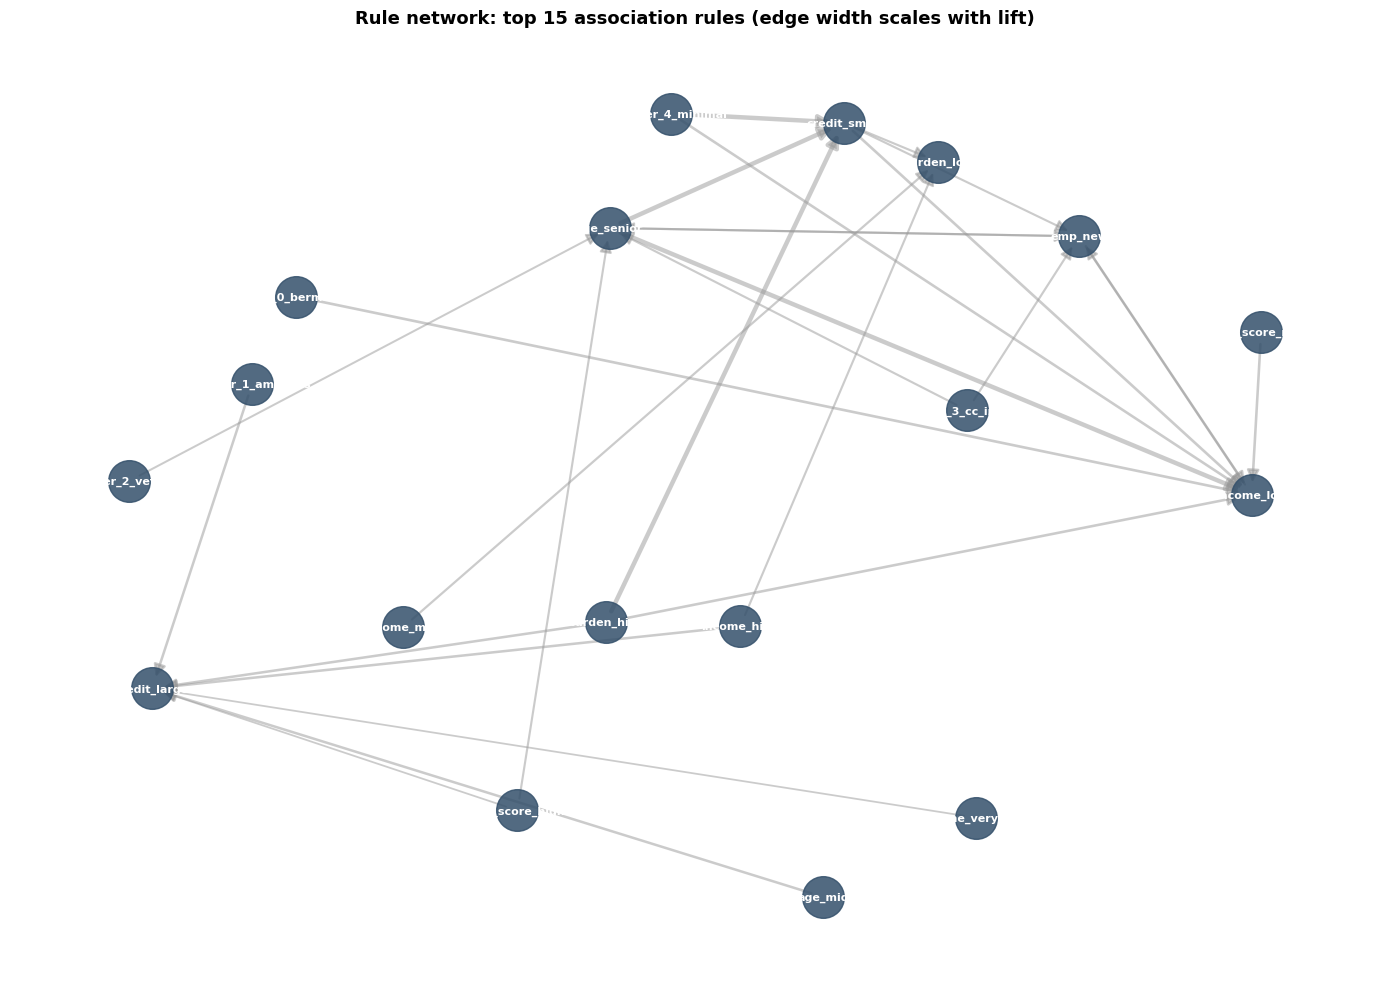

In [10]:
# Rule network: each node is a condition, an edge means the two co-occur in a final rule.
G = nx.DiGraph()
for _, r in top_rules.iterrows():
    parts = str(r['rule_str']).split(' -> ')
    ant_str, con_str = parts[0], (parts[1] if len(parts) == 2 else '')
    clean = lambda s: [i.strip().strip("'") for i in s.replace('{', '').replace('}', '').split(',') if i.strip()]
    for a in clean(ant_str):
        for c in clean(con_str):
            G.add_edge(a, c, lift=r['lift'])

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=RANDOM_SEED)
edge_widths = [G[u][v]['lift'] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_color='#34506B', node_size=900, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w*0.7 for w in edge_widths], alpha=0.5, edge_color='#999', arrowsize=18, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)
ax.set_title('Rule network: top 15 association rules (edge width scales with lift)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_rule_network.png', dpi=150, bbox_inches='tight')
plt.show()

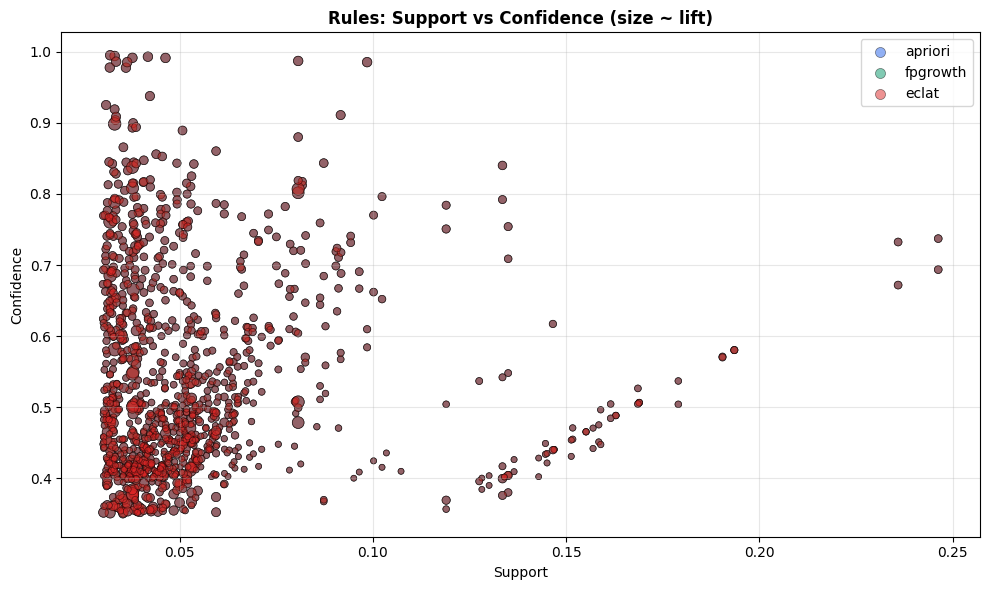

In [11]:
# Scatter support vs confidence per algoritma
fig, ax = plt.subplots(figsize=(10, 6))
algo_colors = {'apriori': '#2563EB', 'fpgrowth': '#059669', 'eclat': '#DC2626'}
for algo_name, color in algo_colors.items():
    df_a = {'apriori': rules_apriori, 'fpgrowth': rules_fp, 'eclat': rules_eclat}[algo_name]
    if len(df_a):
        ax.scatter(df_a['support'], df_a['confidence'], s=df_a['lift']*15, c=color, label=algo_name, alpha=0.5, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
ax.set_title('Rules: Support vs Confidence (size ~ lift)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_scatter_algo.png', dpi=150)
plt.show()

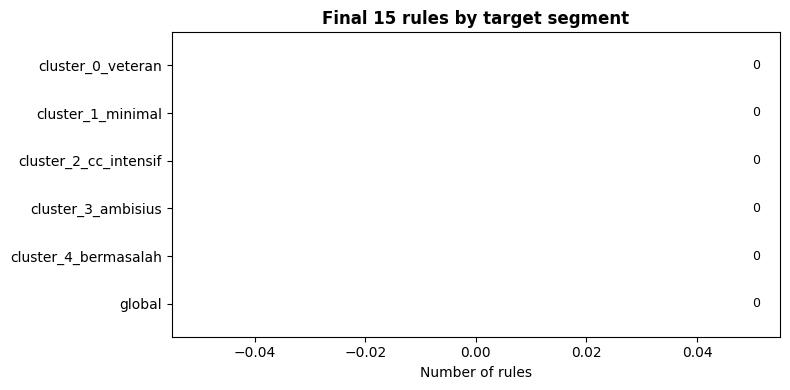

In [12]:
# Heatmap: distribusi rules per cluster
cluster_counts = top_rules['target_cluster'].value_counts().reindex(
    ['cluster_0_veteran','cluster_1_minimal','cluster_2_cc_intensif','cluster_3_ambisius','cluster_4_bermasalah','global'], fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
colors_h = ['#2563EB','#059669','#DC2626','#D97706','#7C3AED','#6B7280']
bars = ax.barh(range(len(cluster_counts)), cluster_counts.values, color=colors_h)
ax.set_yticks(range(len(cluster_counts)))
ax.set_yticklabels(cluster_counts.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Number of rules')
ax.set_title('Final 15 rules by target segment', fontweight='bold')
for bar, val in zip(bars, cluster_counts.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_cluster_heatmap.png', dpi=150)
plt.show()

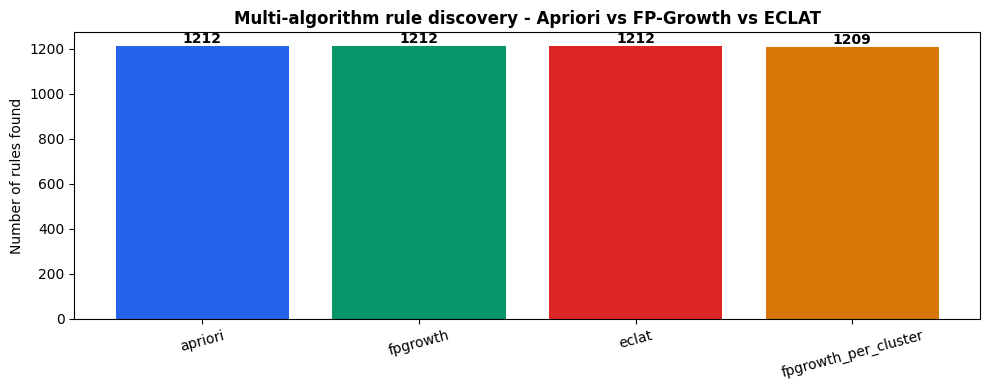

In [13]:
# Algorithm overlap bar
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(algo_df['Algoritma'], algo_df['Rules'], color=['#2563EB','#059669','#DC2626','#D97706'][:len(algo_df)])
ax.set_ylabel('Number of rules found')
ax.set_title('Multi-algorithm rule discovery - Apriori vs FP-Growth vs ECLAT', fontweight='bold')
for i, v in enumerate(algo_df['Rules']):
    ax.text(i, v + max(algo_df['Rules'])*0.01, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_algo_comparison.png', dpi=150)
plt.show()

---
Phase 3 done. The artefacts are in `results/phase3_association/`.